**Assignment 2**


**Question 1**



First we import our needed packages and load the data

In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=0.5, std=1.0)])
dataset = datasets.MNIST(root='../data', download=True, transform=transform)



We then transform our tensors to be the correct size (60000, 784) and also centre the columns of X.

In [2]:
X = dataset.data.float().reshape(len(dataset), -1)
column_means = X.mean(dim=0, keepdim=True)
X -= column_means
print(X.shape)

torch.Size([60000, 784])


We can now compute the SVD of X

In [3]:
U, S, Vh = torch.linalg.svd(X, full_matrices=False)
print("Shape of U, S and Vh:\n", U.shape, S.shape, Vh.shape)

Shape of U, S and Vh:
 torch.Size([60000, 784]) torch.Size([784]) torch.Size([784, 784])


After computing the SVD of X we can now pull out the first 2 principal directions from our Matrix V

In [4]:
# First two principal directions
V_2 = Vh[:2, :].T           # shape: [784, 2]

# PCA coordinates for every image
X_pca = X @ V_2    # shape: [60000, 2]

print(X_pca.shape)

torch.Size([60000, 2])


And then plot them as so:

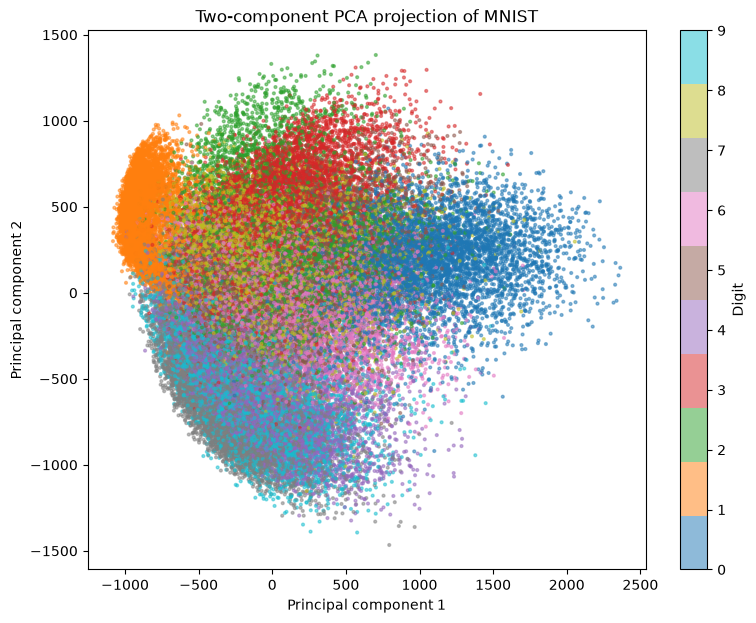

In [5]:
labels = dataset.targets

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca[:, 0].cpu(),
    X_pca[:, 1].cpu(),
    c=labels.cpu(),
    cmap="tab10",
    s=4,
    alpha=0.5
)

plt.colorbar(scatter, label="Digit")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Two-component PCA projection of MNIST")
plt.show()

In this plot of the 2 principal components of our data whilst there is a lot of data and a fair amount of crossover you can also see that each digit is largely clustered similarly with their other digits. 

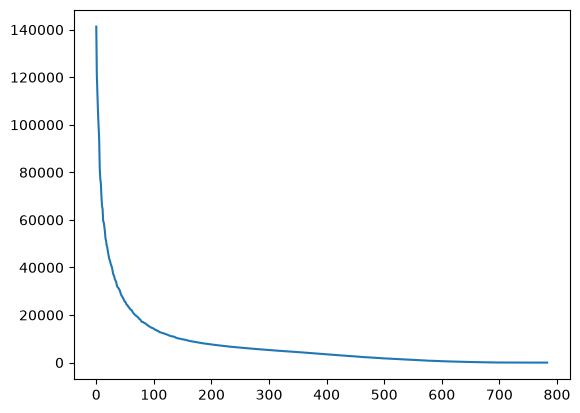

In [24]:
plt.plot(S)

**Is there an "elbow"; or equivalently, do a small number of singular values explain most of the variance in the data?**

The scree plot shows an initial steep decrease in the singular values followed by a gradual flattenning. There is a "elbow", however, it is fairly broad and there is no one point at which it is flat. This shows that the inital componenets account for much of the total variance.



With reference to your answer to the previous part, explain whether PCA could be used to form a low dimensional representation of the dataset.

PCA can be used to form a low representation of the dataset, since the decreasing singular values show that most of the information can be gained from the first $\approx85$ singular values, and you also would not need that many to be able to retain much of the information in the data. You would need more than the 2 used in this example, but it should be considerably smaller than the 784 from the original data. 

**Question 2**

Research a second dimension reduction technique (there are possibilities listed in the text) and implement it to generate a similar (in nature) two-dimensional scatter plot to the one shown above.

The second dimension reduction technique I am choosing to implement is a Variational AutoEncoder (VAE), I chose this because of our transition toward deep learning in this course. 

Epoch 1: loss = 189.9630
Epoch 2: loss = 167.8500
Epoch 3: loss = 163.7473
Epoch 4: loss = 161.5546
Epoch 5: loss = 159.9832
Epoch 6: loss = 158.7649
Epoch 7: loss = 157.7328
Epoch 8: loss = 156.8379
Epoch 9: loss = 156.0722
Epoch 10: loss = 155.2957


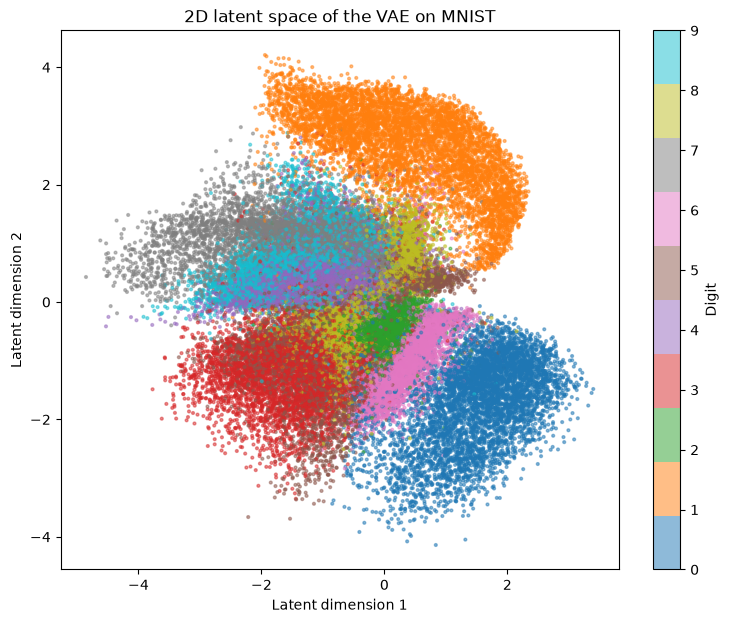

In [6]:

X_VAE = dataset.data.float().reshape(len(dataset), -1) / 255.0

latent_dim = 2

class VAE(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(784, 400),
            torch.nn.ReLU()
        )
        self.mu_head = torch.nn.Linear(400, latent_dim)
        self.logvar_head = torch.nn.Linear(400, latent_dim)

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 400),
            torch.nn.ReLU(),
            torch.nn.Linear(400, 784),
            torch.nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

def loss_function(recon_x, x, mu, logvar):
    BCE = torch.nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

loader = torch.utils.data.DataLoader(
    X_VAE,
    batch_size=128,
    shuffle=True
)

for epoch in range(1, 11):
    model.train()
    total_loss = 0.0

    for batch_x in loader:
        optimizer.zero_grad()
        recon, mu, logvar = model(batch_x)
        loss = loss_function(recon, batch_x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}: loss = {total_loss / len(X_VAE):.4f}")

with torch.no_grad():
    mu, _ = model.encode(X_VAE)
    z = mu.numpy()

labels = dataset.targets.numpy()

plt.figure(figsize=(9, 7))
plt.scatter(z[:, 0], z[:, 1], c=labels, cmap="tab10", s=4, alpha=0.5)
plt.colorbar(label="Digit")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("2D latent space of the VAE on MNIST")
plt.show()

**Question 3**

**Question 4**